# DINOv3 零样本分类 - CPU 测试版

本 notebook 演示如何使用 DINOv3 进行图像特征提取和零样本分类。

## 权重说明

| 权重文件 | 用途 | 状态 |
|---------|------|------|
| `dinov3_vits16_pretrain_lvd1689m-08c60483.pth` | ViT-S Backbone | ✅ 已下载 |
| `dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth` | ViT-B Backbone | ✅ 已下载 |
| `dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth` | ViT-L Backbone | ✅ 已下载 |
| `dinov3_vitl16_dinotxt_*` | Text Encoder (dino.txt) | ⚠️ 需额外申请 |

## 1. 环境配置

In [17]:
import os
import urllib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF

print(f"PyTorch 版本: {torch.__version__}")
print(f"使用设备: CPU")

PyTorch 版本: 2.10.0+cpu
使用设备: CPU


## 2. 加载 DINOv3 Backbone

使用已下载的 backbone 权重进行图像特征提取。

In [18]:
REPO_DIR = r'd:\AI\Git\dinov3.git'

# 轻量模型
# WEIGHTS_PATH = 'dinov3_vits16_pretrain_lvd1689m-08c60483.pth'  # 申请后获得的权重
# Model_ID='dinov3_vits16'

# 高等第一档
WEIGHTS_PATH = r'd:\AI\Git\dinov3.git\notebooks\dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth'
Model_ID='dinov3_vitl16'

model = torch.hub.load(
    repo_or_dir=REPO_DIR,
    model=Model_ID,
    source='local',
    weights=WEIGHTS_PATH
)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"\n✓ 模型加载成功! 参数量: {total_params / 1e6:.1f}M")


✓ 模型加载成功! 参数量: 303.2M


## 3. 加载测试图像

正在加载测试图像...
图像尺寸: (640, 480)


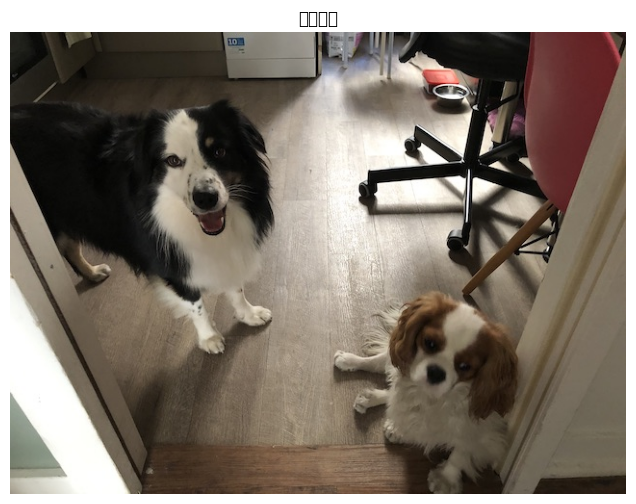

In [19]:
def load_image_from_url(url: str) -> Image.Image:
    """从 URL 加载图片"""
    with urllib.request.urlopen(url) as f:
        return Image.open(f).convert("RGB")

def load_image_from_path(path: str) -> Image.Image:
    """从本地路径加载图片"""
    return Image.open(path).convert("RGB")

# 加载示例图片
EXAMPLE_IMAGE_URL = "example.jpg"

print("正在加载测试图像...")
img_pil =  load_image_from_path(EXAMPLE_IMAGE_URL)

print(f"图像尺寸: {img_pil.size}")
plt.figure(figsize=(8, 6))
plt.imshow(img_pil)
plt.axis('off')
plt.title("测试图像")
plt.show()

## 4. 图像预处理

In [20]:
# 使用 DINOv3 的标准预处理
from dinov3.data.transforms import make_classification_eval_transform

IMAGE_SIZE = 224
PATCH_SIZE = 16
PATCHES_PER_SIDE = IMAGE_SIZE // PATCH_SIZE

image_preprocess = make_classification_eval_transform(
    resize_size=256,
    crop_size=224,
)

# 预处理图像
image_tensor = image_preprocess(img_pil).unsqueeze(0)  # [1, 3, 224, 224]
print(f"预处理后张量形状: {image_tensor.shape}")

预处理后张量形状: torch.Size([1, 3, 224, 224])


## 5. 提取图像特征

In [21]:
print("提取特征中...")

with torch.inference_mode():
    # 获取 CLS token 特征 (用于图像级表示)
    cls_features = model(image_tensor)
    
    # 获取 patch 级特征 (用于分割等)
    patch_features = model.get_intermediate_layers(
        image_tensor,
        n=1,  # 最后一层
        reshape=True,
        norm=True,
    )[0].squeeze(0)  # [dim, h, w]

print(f"CLS 特征形状: {cls_features.shape}")
print(f"Patch 特征形状: {patch_features.shape}")

# L2 归一化
cls_features_norm = F.normalize(cls_features, p=2, dim=1)
print(f"归一化后: {cls_features_norm.shape}")

提取特征中...
CLS 特征形状: torch.Size([1, 1024])
Patch 特征形状: torch.Size([1024, 14, 14])
归一化后: torch.Size([1, 1024])


## 6. Patch 特征 PCA 可视化

特征维度: 1024
Patch 网格: 14x14
PCA 解释方差比: [0.280672   0.12427635 0.09820915]
总解释方差: 50.32%


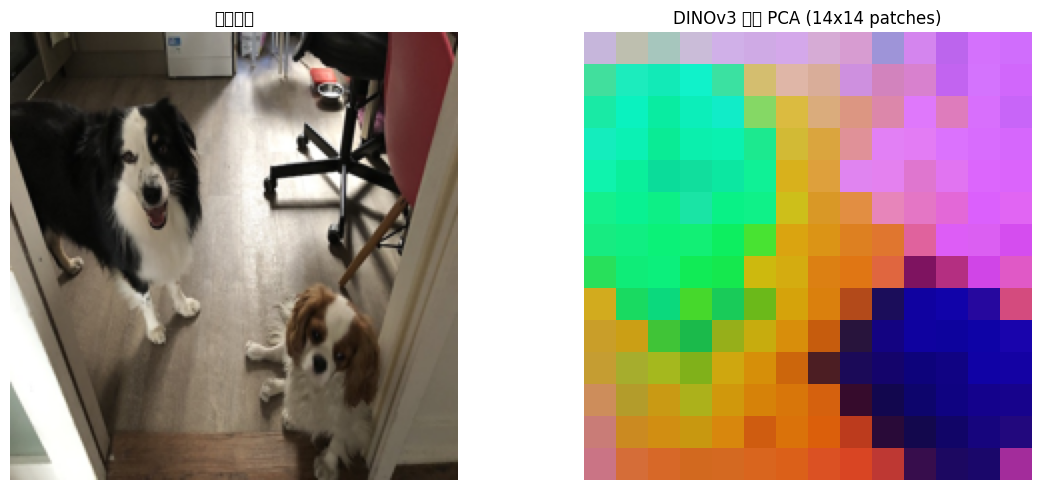

In [22]:
from sklearn.decomposition import PCA

# 获取特征维度
feature_dim = patch_features.shape[0]  # 第一维是特征维度
h_patches, w_patches = patch_features.shape[1], patch_features.shape[2]

# 准备特征矩阵: [C, H, W] -> [H*W, C]
features_flat = patch_features.view(feature_dim, -1).permute(1, 0).numpy()

# PCA 降维
pca = PCA(n_components=3, whiten=True)
features_pca = pca.fit_transform(features_flat)

print(f"特征维度: {feature_dim}")
print(f"Patch 网格: {h_patches}x{w_patches}")
print(f"PCA 解释方差比: {pca.explained_variance_ratio_}")
print(f"总解释方差: {sum(pca.explained_variance_ratio_):.2%}")

# 可视化
pca_image = features_pca.reshape(h_patches, w_patches, 3)
pca_tensor = torch.from_numpy(pca_image).float()
pca_normalized = torch.sigmoid(pca_tensor.mul(2.0))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_pil.resize((IMAGE_SIZE, IMAGE_SIZE)))
axes[0].set_title('原始图像')
axes[0].axis('off')
axes[1].imshow(pca_normalized.numpy())
axes[1].set_title(f'DINOv3 特征 PCA ({h_patches}x{w_patches} patches)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 7. Patch 相似度检索

使用 DINOv3 特征进行 patch 级别的相似度检索。点击图像选择一个 patch，查看相似度分布。

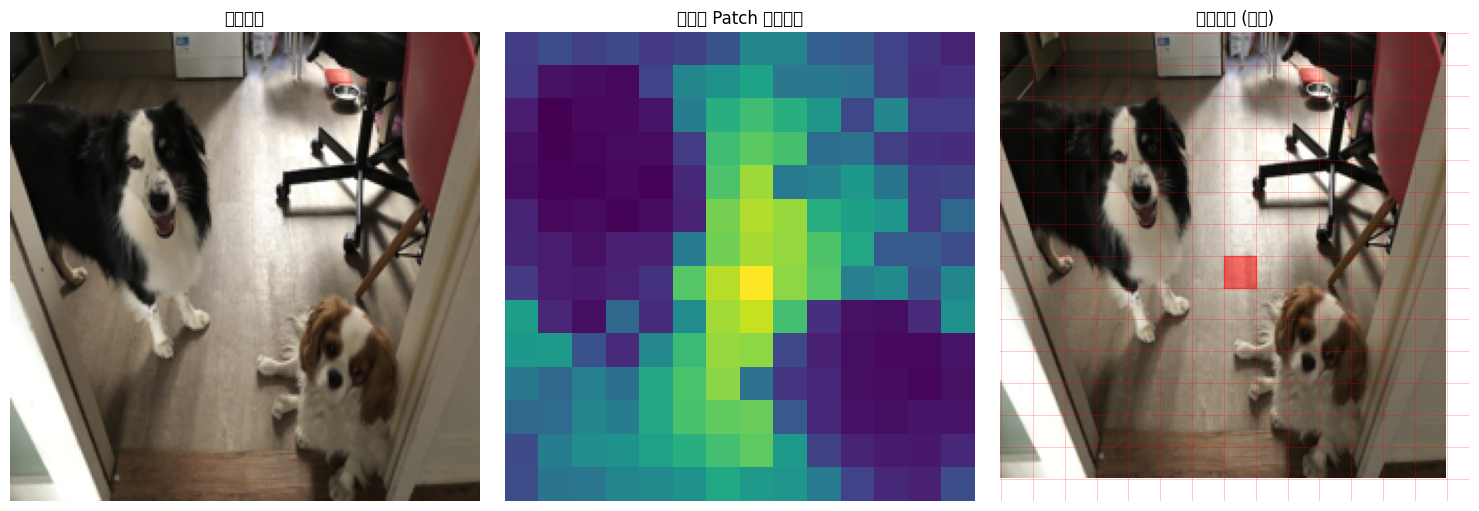

In [23]:
# 计算所有 patch 之间的相似度
feature_dim = patch_features.shape[0]
patch_features_flat = patch_features.view(feature_dim, -1).permute(1, 0)  # [num_patches, dim]
patch_features_norm = F.normalize(patch_features_flat, p=2, dim=1)

# 选择中心 patch 作为查询
center_idx = h_patches // 2 * w_patches + w_patches // 2
query_feature = patch_features_norm[center_idx:center_idx+1]

# 计算相似度
similarities = torch.mm(query_feature, patch_features_norm.T).squeeze(0)
similarity_map = similarities.reshape(h_patches, w_patches).numpy()

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_pil.resize((IMAGE_SIZE, IMAGE_SIZE)))
axes[0].set_title('原始图像')
axes[0].axis('off')

axes[1].imshow(similarity_map, cmap='viridis')
axes[1].set_title('与中心 Patch 的相似度')
axes[1].axis('off')

# 标记中心点
axes[2].imshow(img_pil.resize((IMAGE_SIZE, IMAGE_SIZE)))
axes[2].set_title('查询位置 (中心)')
axes[2].axis('off')
# 绘制网格
for i in range(h_patches + 1):
    axes[2].axhline(y=i * PATCH_SIZE, color='red', linewidth=0.5, alpha=0.3)
for j in range(w_patches + 1):
    axes[2].axvline(x=j * PATCH_SIZE, color='red', linewidth=0.5, alpha=0.3)
# 标记中心 patch
center_y = (h_patches // 2) * PATCH_SIZE
center_x = (w_patches // 2) * PATCH_SIZE
rect = plt.Rectangle((center_x, center_y), PATCH_SIZE, PATCH_SIZE, 
                      fill=True, color='red', alpha=0.5)
axes[2].add_patch(rect)

plt.tight_layout()
plt.show()

## 8. dino.txt 零样本分类

使用本地下载的 text encoder 权重进行零样本分类。

**权重文件:** `notebook\dinov3_vitl16_dinotxt_vision_head_and_text_encoder-a442d8f5.pth`

In [24]:
# ============================================================
# dino.txt 零样本分类示例 (直接从本地加载权重)
# ============================================================

from dinov3.hub.dinotxt import dinov3_vitl16_dinotxt_tet1280d20h24l
from dinov3.hub.backbones import dinov3_vitl16

REPO_DIR = r'd:\AI\Git\dinov3.git'

# 本地权重路径 (使用绝对路径)
DINOTXT_WEIGHTS_PATH = r"d:\AI\Git\dinov3.git\notebooks\dinov3_vitl16_dinotxt_vision_head_and_text_encoder-a442d8f5.pth"
# BPE 词表 (本地路径)
BPE_PATH = r"d:\AI\Git\dinov3.git\notebooks\bpe_simple_vocab_16e6.txt.gz"

print("正在加载 dino.txt 模型...")
print(f"DINOTXT_WEIGHTS_PATH: {DINOTXT_WEIGHTS_PATH}")
print(f"BPE_PATH: {BPE_PATH}")

# 方法: 使用 pretrained=False 避免自动下载，然后手动加载本地权重
# 1. 先创建不带预训练权重的模型
from dinov3.eval.text.dinotxt_model import DINOTxt, DINOTxtConfig
from dinov3.eval.text.text_transformer import TextTransformer
from dinov3.eval.text.tokenizer import Tokenizer
import math

# 配置
dinotxt_config = DINOTxtConfig(
    embed_dim=2048,
    vision_model_freeze_backbone=True,
    vision_model_train_img_size=224,
    vision_model_use_class_token=True,
    vision_model_use_patch_tokens=True,
    vision_model_num_head_blocks=2,
    vision_model_head_blocks_drop_path=0.3,
    vision_model_use_linear_projection=False,
    vision_model_patch_tokens_pooler_type="mean",
    vision_model_patch_token_layer=1,
    text_model_freeze_backbone=False,
    text_model_num_head_blocks=0,
    text_model_head_blocks_is_causal=False,
    text_model_head_blocks_drop_prob=0.0,
    text_model_tokens_pooler_type="argmax",
    text_model_use_linear_projection=True,
    init_logit_scale=math.log(1 / 0.07),
    init_logit_bias=None,
    freeze_logit_scale=False,
)

# 2. 从本地加载 backbone (使用之前已加载的模型或重新加载)
vision_backbone = dinov3_vitl16(pretrained=False)
backbone_state_dict = torch.load(WEIGHTS_PATH, map_location='cpu', weights_only=True)
vision_backbone.load_state_dict(backbone_state_dict, strict=True)
print("✓ Backbone 权重加载完成")

# 3. 创建 text backbone
text_backbone = TextTransformer(
    context_length=77,
    vocab_size=49408,
    dim=1280,
    num_heads=20,
    num_layers=24,
    ffn_ratio=4,
    is_causal=True,
    ls_init_value=None,
    dropout_prob=0.0,
)

# 4. 创建完整模型
model_dinotxt = DINOTxt(
    model_config=dinotxt_config,
    vision_backbone=vision_backbone,
    text_backbone=text_backbone
)
model_dinotxt.visual_model.backbone = vision_backbone
model_dinotxt.eval()

# 5. 从本地加载 dino.txt 权重 (vision head + text encoder)
dinotxt_state_dict = torch.load(DINOTXT_WEIGHTS_PATH, map_location='cpu', weights_only=True)
model_dinotxt.load_state_dict(dinotxt_state_dict, strict=False)
print("✓ dino.txt 权重加载完成")

# 6. 获取 tokenizer (直接读取本地文件，绕过 get_tokenizer 的 URL 检测问题)
from io import BytesIO
with open(BPE_PATH, "rb") as f:
    bpe_buffer = BytesIO(f.read())
tokenizer = Tokenizer(vocab_path=bpe_buffer)
print("✓ Tokenizer 加载完成")

# 定义类别
texts = ["photo of dogs", "photo of a chair", "photo of a bowl", "photo of a tupperware"]
tokenized_texts = tokenizer.tokenize(texts)

# 编码图像和文本
with torch.no_grad():
    image_features = model_dinotxt.encode_image(image_tensor)
    text_features = model_dinotxt.encode_text(tokenized_texts)

# 归一化并计算相似度
image_features = F.normalize(image_features, p=2, dim=1)
text_features = F.normalize(text_features, p=2, dim=1)
similarity = (text_features @ image_features.T).squeeze()

# 输出结果
print("\n零样本分类结果:")
print("="*40)
for i, text in enumerate(texts):
    print(f"  {text}: {similarity[i].item():.3f}")

prediction = texts[similarity.argmax()]
print(f"\n预测: {prediction}")

正在加载 dino.txt 模型...
DINOTXT_WEIGHTS_PATH: d:\AI\Git\dinov3.git\notebooks\dinov3_vitl16_dinotxt_vision_head_and_text_encoder-a442d8f5.pth
BPE_PATH: d:\AI\Git\dinov3.git\notebooks\bpe_simple_vocab_16e6.txt.gz
✓ Backbone 权重加载完成
✓ dino.txt 权重加载完成
✓ Tokenizer 加载完成

零样本分类结果:
  photo of dogs: 0.167
  photo of a chair: 0.064
  photo of a bowl: 0.040
  photo of a tupperware: 0.049

预测: photo of dogs


## 9. 替代方案: 使用 CLIP 进行零样本分类

如果暂时没有 dino.txt 权重，可以使用 CLIP 进行零样本分类。

正在加载 CLIP 模型...

零样本分类结果 (CLIP):
  dog            : 98.32%
  cat            : 0.10%
  bird           : 0.04%
  car            : 0.08%
  tree           : 0.01%
  chair          : 0.12%
  bowl           : 0.66%
  tupperware     : 0.68%

预测类别: dog


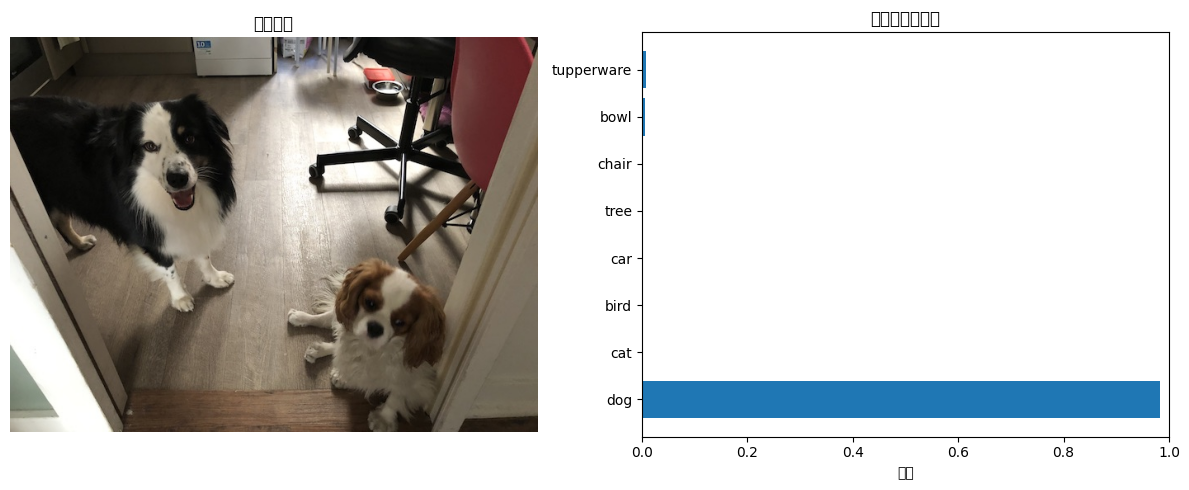

In [25]:
# 使用 Hugging Face CLIP 进行零样本分类
try:
    from transformers import CLIPModel, CLIPProcessor
    
    print("正在加载 CLIP 模型...")
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    clip_model.eval()
    
    # 定义类别
    class_names = ["dog", "cat", "bird", "car", "tree", "chair", "bowl", "tupperware"]
    text_prompts = [f"a photo of a {name}" for name in class_names]
    
    # 处理输入
    inputs = clip_processor(
        text=text_prompts,
        images=img_pil,
        return_tensors="pt",
        padding=True,
    )
    
    # 推理
    with torch.no_grad():
        outputs = clip_model(**inputs)
        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1)
    
    # 显示结果
    print("\n零样本分类结果 (CLIP):")
    print("="*40)
    for name, prob in zip(class_names, probs[0]):
        print(f"  {name:15s}: {prob.item():.2%}")
    
    prediction = class_names[probs.argmax()]
    print(f"\n预测类别: {prediction}")
    
    # 可视化
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_pil)
    axes[0].set_title('输入图像')
    axes[0].axis('off')
    
    axes[1].barh(class_names, probs[0].numpy())
    axes[1].set_xlabel('概率')
    axes[1].set_title('零样本分类结果')
    axes[1].set_xlim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("未安装 transformers，请运行: pip install transformers")

## 10. DINOv3 vs CLIP 对比

| 特性 | DINOv3 Backbone | DINOv3 + dino.txt | CLIP |
|------|----------------|-------------------|------|
| 图像特征提取 | ✅ | ✅ | ✅ |
| 文本编码 | ❌ | ✅ | ✅ |
| 零样本分类 | ❌ | ✅ | ✅ |
| 开放词汇分割 | ❌ | ✅ | ⚠️ 有限 |
| 密集特征质量 | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ |

## 总结

### 已完成
1. ✅ 使用 DINOv3 backbone 提取图像特征
2. ✅ Patch 特征 PCA 可视化
3. ✅ Patch 相似度检索
4. ✅ 使用 CLIP 进行零样本分类

### 下一步
1. 申请 dino.txt 权重: https://ai.meta.com/resources/models-and-libraries/dinov3-downloads/
2. 获取权重后运行 dino.txt 零样本分割

### 学习建议
- DINOv3 backbone 的密集特征非常适合分割、检测等任务
- dino.txt 是 DINOv3 的独有功能，支持文本引导的视觉任务
- 可以结合 DINOv3 特征 + 简单分类器实现自定义分类任务